Geo Data Science with Python,
Prof. Susanna Werth, VT Geosciences

---

# Selecting points inside a boundary

The purpose of this notebook is to introduce some content of the Python module **Shapely** and make use of it's classes for selecting points inside a boundary and generating a regional mask raster.

### Sources
Documentation pages of the module [Shapely](https://shapely.readthedocs.io/en/stable/index.html) and the [Python-GIS page about Shapely](https://automating-gis-processes.github.io/CSC18/lessons/L4/point-in-polygon.html).

---


# Module Shapely

In previous lesson parts, we calculated statistics for gridded data over the entire globe or a certain bounding box (lat/lon box). In a more realistic scenario, we would be interested to retrieve statistics for a certain geographical or political area, like an ocean region (like the Atlatnic), a river basin, a country or a state.

Such boundaries are not lat/lon blocks, but defined by more complex polygons and we cannot simply slice them out of the arrays. To be able to select unregularly shaped region from a data array, we will peak into a module, which provides us with tools to perform exactly that: selecting raster data within a region. As you will see later, this is a very typical Geoscience problem, which reduces to the problem of finding out whether a **point falls inside a polygon**. 

Here, you will learn to do this in Python with the module shapely.

<img src="./Image_Shapely.png" width="500" />

Figure 1: *Fundamental geometric objects that can be used in Python with Shapely module*

## Creating Points and Lines using Shapely

The most fundamental geometric objects are Points, Lines and Polygons which are the basic ingredients when working with spatial data in vector format. Python has a specific module called Shapely, which can be used to create and work with planar geometric objects. There are many useful functionalities that you can do with Shapely such as:

* Create a Line or Polygon from a Collection of Point geometries
* Calculate areas/length/bounds etc. of input geometries
* Make geometric operations based on the input geometries such as Union, Difference, Distance etc.
* Make spatial queries between geometries such Intersects, Touches, Crosses, Within etc.

Geometric Objects consist of coordinate tuples where:

* Point-objects represent a single point in space. Points can be either two-dimensional (x, y) or three dimensional (x, y, z).
* LineString-objects (i.e. a line) represent a sequence of points joined together to form a line. Hence, a line consist of a list of at least two coordinate tuples
* Polygon objects represents a filled area that consists of a list of at least three coordinate tuples that forms the exterior ring and a (possible) list of hole polygons.

Here we will look only into selected parts of the module: **Points and Polygons** and related functions `within()` and `contain()`, which are necessary to perform the final project.

### Point

During a previous lesson, you were coding your a class Point. Shapely offers something similar, but it comes with many more methods and attributes.

Creating a shapely Point is easy, you pass x and y coordinates into a Point()-object:

In [1]:
# Import geometric object Point from shapely module
from shapely.geometry import Point

In [41]:
# Create Point geometric object(s) with coordinates
point1 = Point(2.2, 4.2)
point2 = Point(1, -15.1)
point3 = Point(7.2, -15.1)
point4 = Point(9.26, -2.456)

Let’s see what the variables look like

In [3]:
# printing point 1 to screen
print(point1)

POINT (2.2 4.2)


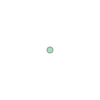

In [4]:
point1

In [5]:
# What is the type of the point?
print(type(point1))

<class 'shapely.geometry.point.Point'>


We can see that the type of the point is shapely’s Point which is represented in a specific format that is based on GEOS C++ library that is one of the standard libraries in GIS.

### Point attributes and functions

The point-object has some built-in attributes that can be accessed and also some useful functionalities. One of the most useful ones are the ability to extract the coordinates of a Point and calculate the Euclidian distance between points.

Extracting the coordinates of a Point can be done in a couple of different ways:

In [6]:
# Get the coordinates
point_coords = point1.coords 

# What is the type of this?
type(point_coords) 

shapely.coords.CoordinateSequence

Ok, we can see that the output is a Shapely CoordinateSequence. Let’s see how we can get out the actual coordinates:

In [7]:
# Get x and y coordinates
xy = point_coords.xy

# Get only x coordinates of Point1
x = point1.x

# Whatabout y coordinate?
y = point1.y

What is inside?

In [8]:
# printing received coordinates of the point
print(xy)

(array('d', [2.2]), array('d', [4.2]))


In [9]:
# printing received x coordinate of the point
print(x)

2.2


In [10]:
# printing received y coordinate of the point
print(y) 

4.2


So we can see that the our xy variable contains a tuple where x and y are stored inside of numpy arrays. However, our x and y variables are plain decimal numbers.

It is also possible to calculate the distance between points which can be useful in many applications. The returned distance is based on the projection of the points (degrees in WGS84, meters in UTM).

In [11]:
# Calculate the distance between point1 and point2
point_dist = point1.distance(point2)
print("Distance between the points is {0:.2f} decimal degrees".format(point_dist))

Distance between the points is 29.72 decimal degrees


## Line

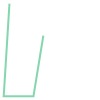

In [42]:
from shapely.geometry import LineString

# An ordered sequence of points is a `LineString'
line = LineString((point1, point2, point3, point4))
line

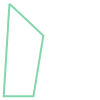

In [43]:
from shapely.geometry import LinearRing

# To make a closed shape, use a `LinearRing'
closed_line = LinearRing(line)
closed_line

In [44]:
# Some of the attributes of the LinearRing..
print(closed_line.area)   # no area since it is not 'filled'
print(closed_line.length) # the perimeter of the shape
print(closed_line.bounds) # an xy-plane bounding box

0.0
48.05086435266904
(1.0, -15.1, 9.26, 4.2)


## Polygon

Creating a shapely-object Polygon continues the same logic of how Point was created but Polygon objects only accept coordinate-tuples as input. A shapely Polygon needs at least three coordinate-tuples:

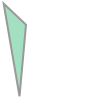

In [78]:
from shapely.geometry import Polygon

# Create a Polygon from the coordinates
poly = Polygon([(2.2, 4.2), (7.2, -25.1), (9.26, -2.456)])
poly

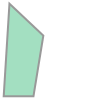

In [80]:
# We can also use our previously created Point objects (same outcome)
# --> notice that Polygon object requires x,y coordinates as input
poly2 = Polygon([[p.x, p.y] for p in [point1, point2, point3, point4]])
poly2

Now, let's make a circle, with some noise

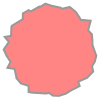

In [104]:
# Let's make a circle, with some noise

import numpy as np

N = 50

x = np.cos(np.linspace(0, 2.0*np.pi, N+1))[:-1] + 0.05*np.random.randn(50)
y = np.sin(np.linspace(0, 2.0*np.pi, N+1))[:-1] + 0.05*np.random.randn(50)

xy = zip(x, y)
poly = Polygon(xy)
poly

### Polygon attributes and functions

We can again access different attributes that are really useful such as:

In [105]:
# Some of the Polygon attributes
print(poly.geom_type)  # does this make sense?
print(poly.area)  # does this make sense?
print(poly.centroid) # get the centroid of the Polygon
print(poly.bounds)   # bounds
print(poly.length)   # bounds


Polygon
3.161945767185941
POINT (-0.0017981305954209 -0.0128213101219526)
(-1.0688748680862754, -1.0404087960427233, 1.015914981610787, 1.0340765458118122)
7.256439876871432


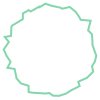

In [106]:
poly_ext = poly.exterior  # exterior polygon
poly.boundary

We can also create 2D objects by adding buffers to existing 0D and 1D objects

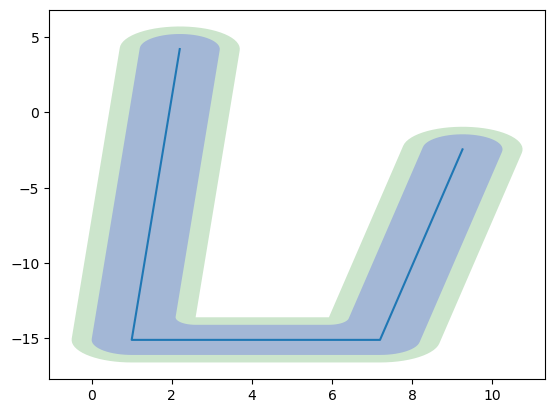

In [107]:
import matplotlib.pyplot as plt

dialated = line.buffer(1.5)
eroded = dialated.buffer(-0.5)

plt.plot(*line.xy)
plt.fill(*dialated.boundary.xy, 'g', alpha=0.2)
plt.fill(*eroded.boundary.xy, 'b', alpha=0.2)
plt.show()

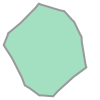

In [120]:
poly.buffer(-0.8)


## Point in Polygon

Finding out if a certain **point is located inside or outside of an area is a fundamental geospatial operation** that is often used, for example, **to select data based on location**. Such spatial queries are one of the typical first steps of the workflow when doing spatial analysis. 

Computationally, detecting if a point is inside a polygon is most commonly done using a specific formula called Ray Casting algorithm. Luckily, we do not need to create such a function ourselves for conducting the **Point in Polygon (PIP)** query. Instead, we can take advantage of Shapely’s binary predicates that can evaluate the topological relationships between geometric objects, such as the PIP as we’re interested here.

There are basically two ways of conducting PIP in Shapely:

* using a function called .within() that checks if a point is within a polygon
* using a function called .contains() that checks if a polygon contains a point

Let’s first again create a Polygon using a list of coordinate-tuples and a couple of Point objects:

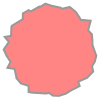

In [127]:
# Create Point objects
p1 = Point(0.2952242, 0.1696017)
p2 = Point(4.4976567, 0.01612500)
poly

Now, let’s check if those points are `within()` the noisy circle polygon

In [128]:
# Check if p1 is within the polygon using the within function
p1.within(poly)

True

In [126]:
# Check if p2 is within the polygon
p2.within(poly)

False

We can see that the first point seems to be inside that polygon and the other one doesn’t.

In fact, the first point is closer to the center of the polygon as we can see:

In [138]:
# Our points distance to the centroid
print(p1.distance(poly.centroid))
print(p2.distance(poly.centroid))

# The centroid
print(poly.centroid)

0.3485691028968137
4.499547939675511
POINT (-0.0017981305954209 -0.0128213101219526)


This works also for lines within polygon, for example the dilated polygon from above should contain the line we originally used to create it:

In [132]:
line.within(dialated)

True

It is also possible to do check other way around, i.e. to check if polygon contains a point or line:

In [135]:
# Does polygon contain p1 and p2?
poly.contains(p1), poly.contains(p2)

(True, False)

In [134]:
# and for the line:
dialated.contains(line)

True

Both ways of checking the spatial relationship results in the same outcome. But which one should you use then? Well, it depends:

If you have **many points and just one polygon** and you try to find out which one of them is inside the polygon:
    
* You need to iterate over the points and check, one at a time, if it is `within()` the polygon specified

If you have **many polygons and just one point** and you want to find out which polygon contains the point

* You iterate over the polygons until you find a polygon that `contains()` the point specified (assuming there are no overlapping polygons).

### Conclusion

The module shapely provides us with data object types for points and polygons (and more). It also comes with function to perform a Point in Polygon (PIP) analysis.
This is definitely not all to know about the module shapely, but the most important functions to move on to analyze our sea surface temperatures for the atlantic ocean only!